Stage 2: Create blk 863B floor layout JSON
- Join 4r_point_end_mirror_y and 4r_point_end, then rotate 90 deg anticlockwise. ENSURE FACADES ARE TRANSFORMED CORRECTLY TOO. Label top room 394 and bottom room 396
- Join 5r_point_end_stairs_mirror_x and 5r_point_end_stairs_mirror_o. Label left room 392 and right room 390
- Gap of 4m (2m clearance + 2m stairs)
- Lowest y coord of 394 = lowest y coord of 392
- Extend corridor facade to left wall of unit 392 masterroom and bedroom2 polyline
- Compact print output
- Include number of stories


In [8]:
import json
from copy import deepcopy
from pathlib import Path

INPUT_JSON = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\unittemplates_rm_mirrors.json")
OUTPUT_JSON = Path(r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\blk863b.json")

GAP = 4.0
NUMBER_STORIES = 4

KEYS = {
    "394": "4r_point_end",
    "396": "4r_point_end_mirror_y",
    "392": "5r_point_end_stairs_mirror_x",
    "390": "5r_point_end_stairs_mirror_o",
}


# ============================================================
# TRANSFORMATIONS
# ============================================================

def edit(unit, transform):
    unit = deepcopy(unit)

    for room in unit["rooms"].values():
        room["coordinates"] = [list(transform(*p)) for p in room["coordinates"]]

    for f in unit.get("facades", []):
        for key in ("start", "end"):
            if key in f:
                f[key] = list(transform(*f[key]))
        if "points" in f:
            f["points"] = [list(transform(*p)) for p in f["points"]]

    return unit


def bounds(unit):
    pts = [p for r in unit["rooms"].values() for p in r["coordinates"]]
    xs, ys = zip(*pts)
    return min(xs), max(xs), min(ys), max(ys)


def move(unit, dx=0, dy=0):
    return edit(unit, lambda x, y: (x + dx, y + dy))


def rotate90(unit):
    return edit(unit, lambda x, y: (-y, x))


def normalise(units):
    min_x = min(bounds(u)[0] for u in units.values())
    min_y = min(bounds(u)[2] for u in units.values())
    return {k: move(u, -min_x, -min_y) for k, u in units.items()}


def join_left_right(left, right):
    lminx, lmaxx, lminy, _ = bounds(left)
    rminx, _, rminy, _ = bounds(right)

    left = move(left, -lminx, -lminy)
    right = move(right, lmaxx - lminx - rminx, -rminy)

    return left, right


# ============================================================
# UNIT 392 CORRIDOR
# ============================================================

def left_wall(unit, room_name):
    """Return bottom and top points of room's left wall."""
    pts = unit["rooms"][room_name]["coordinates"]
    min_x = min(x for x, y in pts)
    pts = sorted(([x, y] for x, y in pts if abs(x - min_x) < 1e-6),
                 key=lambda p: p[1])

    if len(pts) < 2:
        raise ValueError(f"No left wall found for {room_name}")

    return pts[0], pts[-1]


def extend_392_corridor(unit):
    """Add masterroom + bedroom2 left walls to corridor polyline."""
    mb, mt = left_wall(unit, "masterroom")
    b2b, b2t = left_wall(unit, "bedroom2")

    extension = [b2b, b2t, mb, mt]
    extension = [p for i, p in enumerate(extension)
                 if i == 0 or p != extension[i - 1]]

    for f in unit.get("facades", []):
        if f.get("type", "").lower() != "corridor":
            continue

        pts = f.get("points", [])

        if pts and pts[0] == mt:
            f["points"] = extension[:-1] + pts
            return unit

        if pts and pts[-1] == mt:
            f["points"] = pts + list(reversed(extension[:-1]))
            return unit

    raise ValueError("Could not connect Unit 392 left walls to corridor facade.")


# ============================================================
# OUTPUT FORMATTING
# ============================================================

def tidy_polygon(pts):
    pts = [list(p) for p in pts]

    if len(pts) > 1 and pts[0] == pts[-1]:
        pts.pop()

    area = sum(x1*y2 - x2*y1
               for (x1, y1), (x2, y2) in zip(pts, pts[1:] + pts[:1]))

    if area < 0:
        pts.reverse()

    # Start top-right
    i = max(range(len(pts)), key=lambda i: (pts[i][1], pts[i][0]))
    pts = pts[i:] + pts[:i]

    return [[round(x, 3), round(y, 3)] for x, y in pts]


def tidy_facades(unit):
    for f in unit.get("facades", []):
        for key in ("start", "end"):
            if key in f:
                f[key] = [round(v, 3) for v in f[key]]

        if "points" in f:
            f["points"] = [[round(x, 3), round(y, 3)] for x, y in f["points"]]


# ============================================================
# BUILD BLOCK 863B
# ============================================================

def build_block(templates):
    units = {n: deepcopy(templates[k]) for n, k in KEYS.items()}

    # 4R: 396 left, 394 right → rotate 90° anticlockwise
    units["396"], units["394"] = join_left_right(units["396"], units["394"])

    four = normalise({
        "394": rotate90(units["394"]),
        "396": rotate90(units["396"]),
    })

    # 5R: 392 left, 390 right
    units["392"], units["390"] = join_left_right(units["392"], units["390"])

    five = normalise({
        "392": units["392"],
        "390": units["390"],
    })

    # Put 5R pair GAP metres right of 394 and align lowest y
    dx = bounds(four["394"])[1] + GAP - bounds(five["392"])[0]
    dy = bounds(four["394"])[2] - bounds(five["392"])[2]

    five = {n: move(u, dx, dy) for n, u in five.items()}

    # Add 392 masterroom + bedroom2 left walls to corridor facade
    five["392"] = extend_392_corridor(five["392"])

    units = normalise({
        "394": four["394"],
        "396": four["396"],
        "392": five["392"],
        "390": five["390"],
    })

    for u in units.values():
        for room in u["rooms"].values():
            room["coordinates"] = tidy_polygon(room["coordinates"])
        tidy_facades(u)

    return units


# ============================================================
# SAVE COMPACT JSON
# ============================================================

def save_json(data, path):
    lines = ["{"]
    units = list(data.items())

    for i, (num, unit) in enumerate(units):
        lines += [f'    "{num}": {{', '        "rooms": {']

        rooms = list(unit["rooms"].items())
        for j, (name, room) in enumerate(rooms):
            comma = "," if j < len(rooms) - 1 else ""
            s = json.dumps(room, separators=(",", ":"))
            lines.append(f'            "{name}": {s}{comma}')

        facades = json.dumps(unit.get("facades", []), separators=(",", ":"))

        lines += [
            "        },",
            f'        "facades": {facades}',
            "    },"
        ]

    lines.append(f'    "numberStories": {NUMBER_STORIES}')
    lines.append("}")

    path.write_text("\n".join(lines), encoding="utf-8")


# ============================================================
# MAIN
# ============================================================

def main():
    with INPUT_JSON.open(encoding="utf-8") as f:
        templates = json.load(f)

    units = build_block(templates)
    save_json(units, OUTPUT_JSON)

    gap = bounds(units["392"])[0] - bounds(units["394"])[1]

    print(f"Saved: {OUTPUT_JSON}")
    print(f"Lowest y: 394={bounds(units['394'])[2]:.3f}, "
          f"392={bounds(units['392'])[2]:.3f}")
    print(f"Gap: {gap:.3f} m")


if __name__ == "__main__":
    main()

Saved: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\blk863b.json
Lowest y: 394=12.610, 392=12.610
Gap: 4.000 m


Stage 3: Testing - single story
- Convert into IDF but no multiple stories (ignores numberStories)
- Generates base blk 863b template


In [ ]:
"""Build a one-storey EnergyPlus model from blk863b.json.

Designed for EnergyPlus 9.1 + geomeppy and based on the geometry workflow used
in OneBlock.ipynb.

Final modelling assumptions
---------------------------
* Every room polygon is an EnergyPlus Zone.
* Only masterroom, bedroom and living rooms receive Ideal Loads HVAC.
* Thermostat: 20 C heating / 25 C cooling.
* Humidity control: 30% RH minimum / 60% RH maximum.
* Bedrooms/masterrooms: 0.2 ACH infiltration.
* Living rooms: 0.2 ACH while AC is on, 1.0 ACH while AC is off.
* Other rooms: 1.0 ACH infiltration.
* Floor: Adiabatic, NoSun, NoWind.
* Ceiling/top roof: Adiabatic, NoSun, NoWind.
* Ordinary exterior walls: Outdoors, SunExposed, WindExposed.
* Windows are created ONLY on JSON facades labelled window.
* Corridor facades: Outdoors, NoSun, WindExposed.
"""

import json
import math

from geomeppy import IDF


# ============================================================
# USER SETTINGS
# ============================================================

FLOOR_HEIGHT = 2.8

WALL_CONSTRUCTION = "Project Wall"
FLOOR_CONSTRUCTION = "Project Floor"
ROOF_CONSTRUCTION = "Project Flat Roof"
CEILING_CONSTRUCTION = "Project Ceiling"
WINDOW_CONSTRUCTION = "Project External Window"

# These names intentionally match idf_template_SL.idf exactly.
ALWAYS_ON_SCHEDULE = "Always On"
AC_NORMAL_SCHEDULE = "AirCon_normal"
AC_24HR_SCHEDULE = "AirCon_24hr"

# Change this to AC_24HR_SCHEDULE for the 24-hour AC scenario.
AC_SCHEDULE = AC_NORMAL_SCHEDULE

# OneBlock naming convention for generated control objects.
THERMOSTAT_NAME = "Zone Stat"
LIVING_INFILTRATION_SCHEDULE = "Living_Infiltration_AirCon"

HEATING_SETPOINT = 20.0
COOLING_SETPOINT = 25.0
MIN_RH = 30.0
MAX_RH = 60.0

GEOMETRY_TOLERANCE = 1.0e-5


# ============================================================
# 1. INITIALISE IDF
# ============================================================

def initialise_idf(idd_path, idf_template_path):
    """Load the EnergyPlus 9.1 IDD and the empty IDF template."""
    IDF.setiddname(idd_path)
    idf_temp = IDF(idf_template_path)
    _validate_template_names(idf_temp)
    return idf_temp


# ============================================================
# GENERAL HELPERS
# ============================================================

def load_block_json(json_path):
    with open(json_path, "r", encoding="utf-8") as file:
        return json.load(file)


def get_named_object(idf_temp, object_type, name):
    """Return an IDF object with the requested Name, or None."""
    for obj in idf_temp.idfobjects[object_type.upper()]:
        if str(obj.Name).strip().lower() == name.strip().lower():
            return obj
    return None


def _validate_template_names(idf_temp):
    """Fail early if the loaded IDF is not the expected SL template.

    This keeps the converter tied to the object names already defined in
    idf_template_SL.idf instead of silently creating a second naming scheme.
    """
    required = {
        "CONSTRUCTION": [
            WALL_CONSTRUCTION,
            FLOOR_CONSTRUCTION,
            ROOF_CONSTRUCTION,
            CEILING_CONSTRUCTION,
            WINDOW_CONSTRUCTION,
        ],
        "SCHEDULE:COMPACT": [
            ALWAYS_ON_SCHEDULE,
            AC_NORMAL_SCHEDULE,
            AC_24HR_SCHEDULE,
        ],
        "SCHEDULETYPELIMITS": ["Fraction"],
    }

    missing = []
    for object_type, names in required.items():
        for name in names:
            if get_named_object(idf_temp, object_type, name) is None:
                missing.append(f"{object_type}: {name}")

    if missing:
        raise ValueError(
            "The loaded IDF does not match idf_template_SL.idf. "
            "Missing required template object(s): " + ", ".join(missing)
        )


def room_type_from_zone(zone_name):
    name = zone_name.lower()
    if "masterroom" in name or "master_room" in name:
        return "masterroom"
    if "bedroom" in name:
        return "bedroom"
    if "living" in name:
        return "living"
    return "other"


def _xyz(vertex):
    if hasattr(vertex, "x"):
        return float(vertex.x), float(vertex.y), float(vertex.z)
    return float(vertex[0]), float(vertex[1]), float(vertex[2])


def _wall_xy_segment(wall):
    """Return the XY segment along the bottom edge of a vertical wall."""
    coords = [_xyz(vertex) for vertex in wall.coords]
    min_z = min(point[2] for point in coords)
    bottom = [
        point for point in coords
        if abs(point[2] - min_z) <= GEOMETRY_TOLERANCE
    ]
    if len(bottom) < 2:
        return None
    return (bottom[0][0], bottom[0][1]), (bottom[1][0], bottom[1][1])


def _point_line_distance(point, line_start, line_end):
    px, py = point
    x1, y1 = line_start
    x2, y2 = line_end
    dx = x2 - x1
    dy = y2 - y1
    length = math.hypot(dx, dy)
    if length <= GEOMETRY_TOLERANCE:
        return float("inf")
    return abs((px - x1) * dy - (py - y1) * dx) / length


def _segments_collinear_and_overlap(a1, a2, b1, b2):
    """True when two XY line segments are collinear and overlap."""
    if _point_line_distance(b1, a1, a2) > GEOMETRY_TOLERANCE:
        return False
    if _point_line_distance(b2, a1, a2) > GEOMETRY_TOLERANCE:
        return False

    dx = a2[0] - a1[0]
    dy = a2[1] - a1[1]
    length_sq = dx * dx + dy * dy
    if length_sq <= GEOMETRY_TOLERANCE ** 2:
        return False

    def t_value(point):
        return ((point[0] - a1[0]) * dx + (point[1] - a1[1]) * dy) / length_sq

    tb1 = t_value(b1)
    tb2 = t_value(b2)
    overlap_start = max(0.0, min(tb1, tb2))
    overlap_end = min(1.0, max(tb1, tb2))
    return overlap_end - overlap_start > GEOMETRY_TOLERANCE


def _find_facade_walls(idf_temp, start, end):
    """Find generated wall pieces that overlap a JSON facade segment."""
    start = (float(start[0]), float(start[1]))
    end = (float(end[0]), float(end[1]))
    matched = []

    for wall in idf_temp.getsurfaces("wall"):
        wall_segment = _wall_xy_segment(wall)
        if wall_segment is None:
            continue
        if _segments_collinear_and_overlap(
            wall_segment[0], wall_segment[1], start, end
        ):
            matched.append(wall)
    return matched


def _facade_segments(facade):
    """Yield one or more (start, end) segments from a facade object."""
    if "start" in facade and "end" in facade:
        yield facade["start"], facade["end"]
        return

    points = facade.get("points", [])
    for start, end in zip(points[:-1], points[1:]):
        yield start, end


# ============================================================
# 2. CREATE BLOCK
# ============================================================

def create_block(idf_temp, json_path):
    """Extrude every blk863b room polygon into one 2.8 m EnergyPlus zone."""
    block_data = load_block_json(json_path)

    for unit_number, unit_data in block_data.items():
        if unit_number == "numberStories":
            continue
        for room_name, room_data in unit_data.get("rooms", {}).items():
            # Defensive skip for older floorplan files which contained helper
            # outlines rather than physical rooms.
            if room_name.lower() in {"wholeunit", "roomscombined"}:
                continue

            coordinates = [
                (float(x), float(y))
                for x, y in room_data["coordinates"]
            ]
            if len(coordinates) < 3:
                raise ValueError(
                    f"{unit_number}/{room_name} has fewer than 3 vertices."
                )

            idf_temp.add_block(
                name=f"{unit_number}_{room_name}",
                coordinates=coordinates,
                height=FLOOR_HEIGHT,
                num_stories=1,
            )

    # Splits intersecting surfaces and matches adjacent room boundaries.
    idf_temp.intersect_match()

    # Rename Geomeppy's "Block" prefix to "Unit"
    for zone in idf_temp.idfobjects["ZONE"]:
        if zone.Name.startswith("Block "):
            zone.Name = zone.Name.replace("Block ", "Unit ", 1)

    for surface in idf_temp.idfobjects["BUILDINGSURFACE:DETAILED"]:
        if surface.Name.startswith("Block "):
            surface.Name = surface.Name.replace("Block ", "Unit ", 1)

        if surface.Zone_Name.startswith("Block "):
            surface.Zone_Name = surface.Zone_Name.replace("Block ", "Unit ", 1)

        if (
            surface.Outside_Boundary_Condition_Object
            and surface.Outside_Boundary_Condition_Object.startswith("Block ")
        ):
            surface.Outside_Boundary_Condition_Object = (
                surface.Outside_Boundary_Condition_Object.replace(
                    "Block ", "Unit ", 1
                )
            )

    idf_temp = AddMaterials(idf_temp)
    idf_temp = AssignMaterial(idf_temp)
    idf_temp = AssignFloor(idf_temp)
    idf_temp = AssignCeiling(idf_temp)
    return idf_temp


# ============================================================
# CONSTRUCTIONS + HORIZONTAL BOUNDARIES
# ============================================================
def AddMaterials(idf_temp):
    """Add the specified materials only if they do not already exist."""

    materials = [
        {
            "Name": "ConcreteWall",
            "Roughness": "MediumRough",
            "Thickness": 0.15,
            "Conductivity": 0.8,
            "Density": 2400,
            "Specific_Heat": 880,
            "Thermal_Absorptance": 0.85,
            "Solar_Absorptance": 0.79,
            "Visible_Absorptance": 0.79,
        },
        {
            "Name": "WhitePaint",
            "Roughness": "MediumRough",
            "Thickness": 0.15,
            "Conductivity": 0.8,
            "Density": 2400,
            "Specific_Heat": 880,
            "Thermal_Absorptance": 0.91,
            "Solar_Absorptance": 0.365,
            "Visible_Absorptance": 0.365,
        },
        {
            "Name": "CoolPaint",
            "Roughness": "MediumRough",
            "Thickness": 0.15,
            "Conductivity": 0.8,
            "Density": 2400,
            "Specific_Heat": 880,
            "Thermal_Absorptance": 0.90,
            "Solar_Absorptance": 0.12,
            "Visible_Absorptance": 0.12,
        },
        {
            "Name": "EvaporativePaint",
            "Roughness": "MediumRough",
            "Thickness": 0.15,
            "Conductivity": 0.8,
            "Density": 2400,
            "Specific_Heat": 880,
            "Thermal_Absorptance": 0.95,
            "Solar_Absorptance": 0.09,
            "Visible_Absorptance": 0.09,
        },
        {
            "Name": "Greenwall",
            "Roughness": "MediumRough",
            "Thickness": 0.079,
            "Conductivity": 2.5,
            "Density": 1293,
            "Specific_Heat": 853,
            "Thermal_Absorptance": 0.98,
            "Solar_Absorptance": 0.75,
            "Visible_Absorptance": 0.75,
        },
    ]

    existing_material_names = {
        material.Name.strip().lower()
        for material in idf_template_SL.idfobjects["MATERIAL"]
    }

    for material_data in materials:
        material_name = material_data["Name"].lower()

        if material_name not in existing_material_names:
            idf_template_SL.newidfobject(
                "MATERIAL",
                **material_data,
            )
            existing_material_names.add(material_name)

    return idf_temp

def AssignMaterial(idf_temp):
    """Assign constructions from idf_template_SL.idf."""
    for wall in idf_temp.getsurfaces("wall"):
        wall.Construction_Name = WALL_CONSTRUCTION

    for floor in idf_temp.getsurfaces("floor"):
        floor.Construction_Name = FLOOR_CONSTRUCTION

    for ceiling in idf_temp.getsurfaces("ceiling"):
        ceiling.Construction_Name = CEILING_CONSTRUCTION

    # For a one-storey add_block model, Geomeppy normally calls the top face
    # a roof. It represents our assumed indoor boundary above, so it uses the
    # ceiling construction in this representative-storey model.
    for roof in idf_temp.getsurfaces("roof"):
        roof.Construction_Name = CEILING_CONSTRUCTION

    return idf_temp


def AssignFloor(idf_temp):
    """All bottom faces represent adjacent indoor space below."""
    for surface in idf_temp.getsurfaces("floor"):
        surface.Outside_Boundary_Condition = "Adiabatic"
        surface.Outside_Boundary_Condition_Object = ""
        surface.Sun_Exposure = "NoSun"
        surface.Wind_Exposure = "NoWind"
        surface.Construction_Name = FLOOR_CONSTRUCTION
    return idf_temp


def AssignCeiling(idf_temp):
    """All top faces represent adjacent indoor space above."""
    upper_surfaces = (
        idf_temp.getsurfaces("ceiling")
        + idf_temp.getsurfaces("roof")
    )
    for surface in upper_surfaces:
        surface.Outside_Boundary_Condition = "Adiabatic"
        surface.Outside_Boundary_Condition_Object = ""
        surface.Sun_Exposure = "NoSun"
        surface.Wind_Exposure = "NoWind"
        surface.Construction_Name = CEILING_CONSTRUCTION
    return idf_temp


# ============================================================
# 3. FACADE EXPOSURE
# ============================================================

def AssignFacadeExposure(idf_temp, json_path):
    """Apply solar/wind rules to ordinary, window and corridor facades."""
    block_data = load_block_json(json_path)

    # Start with the normal exterior-wall condition.
    for wall in idf_temp.getsurfaces("wall"):
        if wall.Outside_Boundary_Condition.strip().lower() == "outdoors":
            wall.Sun_Exposure = "SunExposed"
            wall.Wind_Exposure = "WindExposed"
            wall.Construction_Name = WALL_CONSTRUCTION

    # Both explicitly labelled facade types are shaded but wind exposed.
    for unit_number, unit_data in block_data.items():
        if unit_number == "numberStories":
            continue
        for facade in unit_data.get("facades", []):
            facade_type = facade.get("type", "").strip().lower()
            if facade_type not in {"window", "corridor"}:
                continue

            for start, end in _facade_segments(facade):
                matched_walls = _find_facade_walls(idf_temp, start, end)
                outdoor_walls = [
                    wall for wall in matched_walls
                    if wall.Outside_Boundary_Condition.strip().lower() == "outdoors"
                ]

                if not outdoor_walls:
                    print(
                        f"WARNING: no outdoor wall matched {facade_type} facade "
                        f"in unit {unit_number}: {start} -> {end}"
                    )

                for wall in outdoor_walls:
                    if facade_type == "window":
                        wall.Sun_Exposure = "SunExposed"
                        wall.Wind_Exposure = "WindExposed"

                    elif facade_type == "corridor":
                        wall.Sun_Exposure = "NoSun"
                        wall.Wind_Exposure = "WindExposed"

    return idf_temp


# ============================================================
# 4. WINDOWS
# ============================================================

def AssignWindows(idf_temp, json_path):
    """Apply WWR only to JSON facades whose type is 'window'.

    Geomeppy's IDF.set_wwr() operates on all exterior walls. To retain that
    tested Geomeppy geometry command while targeting exact JSON facade walls,
    this helper temporarily marks the other exterior walls as Adiabatic,
    calls set_wwr(), then immediately restores their original boundary
    conditions. The resulting IDF keeps the correct wall conditions.
    """
    block_data = load_block_json(json_path)
    walls_by_wwr = {}
    wall_wwr = {}

    for unit_number, unit_data in block_data.items():
        if unit_number == "numberStories":
            continue
        for facade in unit_data.get("facades", []):
            if facade.get("type", "").strip().lower() != "window":
                continue

            wwr = float(facade.get("WWR", 0.4))
            if not 0.0 <= wwr < 1.0:
                raise ValueError(
                    f"Window WWR must be >= 0 and < 1. Got {wwr} in unit {unit_number}."
                )

            for start, end in _facade_segments(facade):
                matched = [
                    wall for wall in _find_facade_walls(idf_temp, start, end)
                    if wall.Outside_Boundary_Condition.strip().lower() == "outdoors"
                ]
                if not matched:
                    print(
                        f"WARNING: no outdoor wall matched window facade "
                        f"in unit {unit_number}: {start} -> {end}"
                    )

                for wall in matched:
                    if wall.Name in wall_wwr and wall_wwr[wall.Name] != wwr:
                        raise ValueError(
                            f"Wall {wall.Name!r} was assigned two WWR values: "
                            f"{wall_wwr[wall.Name]} and {wwr}."
                        )
                    wall_wwr[wall.Name] = wwr
                    walls_by_wwr.setdefault(wwr, set()).add(wall.Name)

    all_outdoor_walls = [
        wall for wall in idf_temp.getsurfaces("wall")
        if wall.Outside_Boundary_Condition.strip().lower() == "outdoors"
    ]

    for wwr, target_names in walls_by_wwr.items():
        saved_conditions = {}
        try:
            # Hide every non-target outdoor wall from set_wwr().
            for wall in all_outdoor_walls:
                saved_conditions[wall.Name] = wall.Outside_Boundary_Condition
                if wall.Name not in target_names:
                    wall.Outside_Boundary_Condition = "Adiabatic"

            idf_temp.set_wwr(
                wwr=wwr,
                construction=WINDOW_CONSTRUCTION,
                force=False,
            )
        finally:
            # Always restore the actual boundary condition.
            for wall in all_outdoor_walls:
                wall.Outside_Boundary_Condition = saved_conditions[wall.Name]

    return idf_temp


# ============================================================
# 5. THERMAL ZONES / HVAC
# ============================================================

def _ensure_zone_thermostat(idf_temp):
    thermostat = get_named_object(
        idf_temp,
        "HVACTEMPLATE:THERMOSTAT",
        THERMOSTAT_NAME,
    )

    if thermostat is None:
        thermostat = idf_temp.newidfobject(
            "HVACTEMPLATE:THERMOSTAT",
            Name=THERMOSTAT_NAME,
        )

    thermostat.Heating_Setpoint_Schedule_Name = ""
    thermostat.Constant_Heating_Setpoint = ""
    thermostat.Cooling_Setpoint_Schedule_Name = ""
    thermostat.Constant_Cooling_Setpoint = COOLING_SETPOINT

    return idf_temp


def AssignThermalZone(idf_temp, ac_schedule=AC_SCHEDULE):
    """Assign cooling-only Ideal Loads HVAC to bedrooms and masterrooms."""

    idf_temp = _ensure_zone_thermostat(idf_temp)

    if get_named_object(
        idf_temp,
        "SCHEDULE:COMPACT",
        ac_schedule,
    ) is None:
        raise ValueError(
            f"AC schedule {ac_schedule!r} is missing from the IDF template."
        )

    for zone in idf_temp.idfobjects["ZONE"]:
        room_type = room_type_from_zone(zone.Name)

        if room_type not in {"masterroom", "bedroom", "living"}:
            continue

        idf_temp.newidfobject(
            "HVACTEMPLATE:ZONE:IDEALLOADSAIRSYSTEM",
            Zone_Name=zone.Name,
            Template_Thermostat_Name=THERMOSTAT_NAME,
            System_Availability_Schedule_Name=ac_schedule,

            Heating_Limit="NoLimit",
            Heating_Availability_Schedule_Name="Always Off",

            Cooling_Limit="NoLimit",
            Cooling_Availability_Schedule_Name=ac_schedule,

            Dehumidification_Control_Type="Humidistat",
            Dehumidification_Setpoint=MAX_RH,

            Humidification_Control_Type="None",
            Humidification_Setpoint="",

            Outdoor_Air_Method="None",
        )

    return idf_temp


# ============================================================
# 6. INFILTRATION
# ============================================================

def _ensure_living_infiltration_schedule(idf_temp, ac_schedule):
    """Create the living-room 0.2/1.0 ACH multiplier schedule."""
    name = LIVING_INFILTRATION_SCHEDULE
    existing = get_named_object(idf_temp, "SCHEDULE:COMPACT", name)
    if existing is not None:
        return name

    if ac_schedule == AC_NORMAL_SCHEDULE:
        idf_temp.newidfobject(
            "SCHEDULE:COMPACT",
            Name=name,
            Schedule_Type_Limits_Name="Fraction",
            Field_1="Through: 12/31",
            Field_2="For: AllDays",
            Field_3="Until: 07:00",
            Field_4=0.2,
            Field_5="Until: 22:00",
            Field_6=1.0,
            Field_7="Until: 24:00",
            Field_8=0.2,
        )
    elif ac_schedule == AC_24HR_SCHEDULE:
        idf_temp.newidfobject(
            "SCHEDULE:COMPACT",
            Name=name,
            Schedule_Type_Limits_Name="Fraction",
            Field_1="Through: 12/31",
            Field_2="For: AllDays",
            Field_3="Until: 24:00",
            Field_4=0.2,
        )
    else:
        raise ValueError(
            "Living-room infiltration linking is currently defined for "
            f"{AC_NORMAL_SCHEDULE} or {AC_24HR_SCHEDULE}."
        )
    return name


def _add_infiltration(idf_temp, zone_name, ach, schedule_name):
    idf_temp.newidfobject(
        "ZONEINFILTRATION:DESIGNFLOWRATE",
        Name=zone_name + " Infiltration",
        Zone_or_ZoneList_Name=zone_name,
        Schedule_Name=schedule_name,
        Design_Flow_Rate_Calculation_Method="AirChanges/Hour",
        Air_Changes_per_Hour=ach,
        Constant_Term_Coefficient=1.0,
        Temperature_Term_Coefficient=0.0,
        Velocity_Term_Coefficient=0.0,
        Velocity_Squared_Term_Coefficient=0.0,
    )


def AssignInfiltration(idf_temp, ac_schedule=AC_SCHEDULE):
    """Assign the requested room-specific infiltration rates."""
    living_schedule = _ensure_living_infiltration_schedule(idf_temp, ac_schedule)

    for zone in idf_temp.idfobjects["ZONE"]:
        room_type = room_type_from_zone(zone.Name)

        if room_type in {"masterroom", "bedroom"}:
            # Same fixed bedroom assumption used in OneBlock.
            _add_infiltration(
                idf_temp,
                zone.Name,
                0.2,
                ALWAYS_ON_SCHEDULE,
            )

        elif room_type == "living":
            # Base ACH is 1.0 and this schedule multiplies it by 0.2 or 1.0.
            _add_infiltration(idf_temp, zone.Name, 1.0, living_schedule)

        else:
            _add_infiltration(
                idf_temp,
                zone.Name,
                1.0,
                ALWAYS_ON_SCHEDULE,
            )

    return idf_temp


# ============================================================
# 7. COMPLETE ONE-STOREY MODEL
# ============================================================

def add_building_properties(idf_temp, json_path):
    """OneBlock-style wrapper for all non-geometry assignments."""
    idf_temp = AssignFacadeExposure(idf_temp, json_path)
    idf_temp = AssignWindows(idf_temp, json_path)
    idf_temp = AssignThermalZone(idf_temp)
    idf_temp = AssignInfiltration(idf_temp)
    return idf_temp


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    idd_path = r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\Energy+.idd"
    idf_template_path = (
        r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\idf_template_SL.idf"
    )
    JSON_PATH = (
        r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines JSON\blk863b.json"
    )
    OUTPUT = (
        r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\blk_863b_single.idf"
    )

    idf_temp = initialise_idf(idd_path, idf_template_path)
    idf_temp = create_block(idf_temp, JSON_PATH)
    idf_temp = add_building_properties(idf_temp, JSON_PATH)

    idf_temp.save(
        OUTPUT,
        lineendings="default",
        encoding="latin-1",
    )

    print(f"IDF saved to: {OUTPUT}")
    idf_temp.view_model()

Stage 4 (multistorey)
- Reads numberStories from blk863b.json
- Generates every required storey with 2.8 m room height
- Preserves matched horizontal surfaces between adjacent storeys
- Generates the base blk 863B multistorey IDF, create 24hr AC and normal AC conditions
- Note that its not just change HVACTEMPLATE, also need to change ZONEINFILTRATION for living room  from livingroom_schedule 1 ACH to always on 0.2 ACH


Saved normal case: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\blk863b_normal.idf
Saved 24-hour case: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\blk863b_24hAC.idf


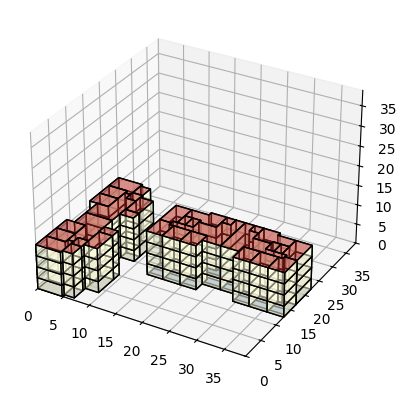

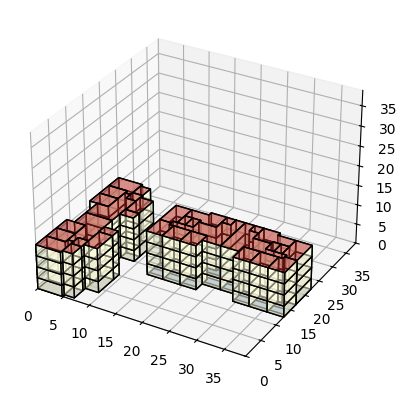

In [2]:
import json
import math
from shutil import copy2
from geomeppy import IDF
FLOOR_HEIGHT = 2.8
WALL_CONSTRUCTION = 'Project Wall'
FLOOR_CONSTRUCTION = 'Project Floor'
ROOF_CONSTRUCTION = 'Project Flat Roof'
CEILING_CONSTRUCTION = 'Project Ceiling'
WINDOW_CONSTRUCTION = 'Project External Window'
ALWAYS_ON_SCHEDULE = 'Always On'
ALWAYS_OFF_SCHEDULE = 'Always Off'
AC_NORMAL_SCHEDULE = 'AirCon_normal'
AC_24HR_SCHEDULE = 'AirCon_24hr'
THERMOSTAT_NAME = 'Zone Stat'
LIVING_INFILTRATION_SCHEDULE = 'Living_Infiltration_AirCon'
COOLING_SETPOINT = 25.0
MAX_RH = 60.0
GEOMETRY_TOLERANCE = 1e-05

def initialise_idf(idd_path, idf_template_path):
    if IDF.getiddname() is None:
        IDF.setiddname(idd_path)
    idf_temp = IDF(idf_template_path)
    _validate_template_names(idf_temp)
    return idf_temp

def load_block_json(json_path):
    with open(json_path, 'r', encoding='utf-8') as file:
        return json.load(file)

def get_number_stories(block_data):
    value = block_data.get('numberStories')
    if isinstance(value, bool) or not isinstance(value, int) or value < 1:
        raise ValueError('blk863b.json must contain a positive integer numberStories.')
    return value

def get_named_object(idf_temp, object_type, name):
    for obj in idf_temp.idfobjects[object_type.upper()]:
        if str(obj.Name).strip().lower() == name.strip().lower():
            return obj
    return None

def _validate_template_names(idf_temp):
    required = {'CONSTRUCTION': [WALL_CONSTRUCTION, FLOOR_CONSTRUCTION, ROOF_CONSTRUCTION, CEILING_CONSTRUCTION, WINDOW_CONSTRUCTION], 'SCHEDULE:COMPACT': [ALWAYS_ON_SCHEDULE, ALWAYS_OFF_SCHEDULE, AC_NORMAL_SCHEDULE, AC_24HR_SCHEDULE], 'SCHEDULETYPELIMITS': ['Fraction']}
    missing = []
    for object_type, names in required.items():
        for name in names:
            if get_named_object(idf_temp, object_type, name) is None:
                missing.append(f'{object_type}: {name}')
    if missing:
        raise ValueError('The loaded IDF does not match idf_template_SL.idf. Missing required template object(s): ' + ', '.join(missing))

def room_type_from_zone(zone_name):
    name = zone_name.lower()
    if 'masterroom' in name or 'master_room' in name:
        return 'masterroom'
    if 'bedroom' in name:
        return 'bedroom'
    if 'living' in name:
        return 'living'
    return 'other'

def _xyz(vertex):
    if hasattr(vertex, 'x'):
        return (float(vertex.x), float(vertex.y), float(vertex.z))
    return (float(vertex[0]), float(vertex[1]), float(vertex[2]))

def _wall_xy_segment(wall):
    coords = [_xyz(vertex) for vertex in wall.coords]
    min_z = min((point[2] for point in coords))
    bottom = [point for point in coords if abs(point[2] - min_z) <= GEOMETRY_TOLERANCE]
    if len(bottom) < 2:
        return None
    return ((bottom[0][0], bottom[0][1]), (bottom[1][0], bottom[1][1]))

def _point_line_distance(point, line_start, line_end):
    px, py = point
    x1, y1 = line_start
    x2, y2 = line_end
    dx = x2 - x1
    dy = y2 - y1
    length = math.hypot(dx, dy)
    if length <= GEOMETRY_TOLERANCE:
        return float('inf')
    return abs((px - x1) * dy - (py - y1) * dx) / length

def _segments_collinear_and_overlap(a1, a2, b1, b2):
    if _point_line_distance(b1, a1, a2) > GEOMETRY_TOLERANCE:
        return False
    if _point_line_distance(b2, a1, a2) > GEOMETRY_TOLERANCE:
        return False
    dx = a2[0] - a1[0]
    dy = a2[1] - a1[1]
    length_sq = dx * dx + dy * dy
    if length_sq <= GEOMETRY_TOLERANCE ** 2:
        return False

    def t_value(point):
        return ((point[0] - a1[0]) * dx + (point[1] - a1[1]) * dy) / length_sq
    tb1 = t_value(b1)
    tb2 = t_value(b2)
    overlap_start = max(0.0, min(tb1, tb2))
    overlap_end = min(1.0, max(tb1, tb2))
    return overlap_end - overlap_start > GEOMETRY_TOLERANCE

def _find_facade_walls(idf_temp, start, end):
    start = (float(start[0]), float(start[1]))
    end = (float(end[0]), float(end[1]))
    matched = []
    for wall in idf_temp.getsurfaces('wall'):
        wall_segment = _wall_xy_segment(wall)
        if wall_segment is None:
            continue
        if _segments_collinear_and_overlap(wall_segment[0], wall_segment[1], start, end):
            matched.append(wall)
    return matched

def _facade_segments(facade):
    if 'start' in facade and 'end' in facade:
        yield (facade['start'], facade['end'])
        return
    points = facade.get('points', [])
    for start, end in zip(points[:-1], points[1:]):
        yield (start, end)

def create_block(idf_temp, json_path):
    block_data = load_block_json(json_path)
    number_stories = get_number_stories(block_data)
    for unit_number, unit_data in block_data.items():
        if unit_number == 'numberStories':
            continue
        for room_name, room_data in unit_data.get('rooms', {}).items():
            if room_name.lower() in {'wholeunit', 'roomscombined'}:
                continue
            coordinates = [(float(x), float(y)) for x, y in room_data['coordinates']]
            if len(coordinates) < 3:
                raise ValueError(f'{unit_number}/{room_name} has fewer than 3 vertices.')
            idf_temp.add_block(name=f'{unit_number}_{room_name}', coordinates=coordinates, height=FLOOR_HEIGHT * number_stories, num_stories=number_stories)
    idf_temp.intersect_match()
    for zone in idf_temp.idfobjects['ZONE']:
        if zone.Name.startswith('Block '):
            zone.Name = zone.Name.replace('Block ', 'Unit ', 1)
    for surface in idf_temp.idfobjects['BUILDINGSURFACE:DETAILED']:
        if surface.Name.startswith('Block '):
            surface.Name = surface.Name.replace('Block ', 'Unit ', 1)
        if surface.Zone_Name.startswith('Block '):
            surface.Zone_Name = surface.Zone_Name.replace('Block ', 'Unit ', 1)
        if surface.Outside_Boundary_Condition_Object and surface.Outside_Boundary_Condition_Object.startswith('Block '):
            surface.Outside_Boundary_Condition_Object = surface.Outside_Boundary_Condition_Object.replace('Block ', 'Unit ', 1)
    idf_temp = AddMaterials(idf_temp)
    idf_temp = AssignMaterial(idf_temp)
    idf_temp = AssignFloor(idf_temp)
    idf_temp = AssignCeiling(idf_temp)
    return idf_temp

def AddMaterials(idf_temp):
    materials = [{'Name': 'ConcreteWall', 'Roughness': 'MediumRough', 'Thickness': 0.15, 'Conductivity': 0.8, 'Density': 2400, 'Specific_Heat': 880, 'Thermal_Absorptance': 0.85, 'Solar_Absorptance': 0.79, 'Visible_Absorptance': 0.79}, {'Name': 'WhitePaint', 'Roughness': 'MediumRough', 'Thickness': 0.15, 'Conductivity': 0.8, 'Density': 2400, 'Specific_Heat': 880, 'Thermal_Absorptance': 0.91, 'Solar_Absorptance': 0.365, 'Visible_Absorptance': 0.365}, {'Name': 'CoolPaint', 'Roughness': 'MediumRough', 'Thickness': 0.15, 'Conductivity': 0.8, 'Density': 2400, 'Specific_Heat': 880, 'Thermal_Absorptance': 0.9, 'Solar_Absorptance': 0.12, 'Visible_Absorptance': 0.12}, {'Name': 'EvaporativePaint', 'Roughness': 'MediumRough', 'Thickness': 0.15, 'Conductivity': 0.8, 'Density': 2400, 'Specific_Heat': 880, 'Thermal_Absorptance': 0.95, 'Solar_Absorptance': 0.09, 'Visible_Absorptance': 0.09}, {'Name': 'Greenwall', 'Roughness': 'MediumRough', 'Thickness': 0.079, 'Conductivity': 2.5, 'Density': 1293, 'Specific_Heat': 853, 'Thermal_Absorptance': 0.98, 'Solar_Absorptance': 0.75, 'Visible_Absorptance': 0.75}]
    existing_material_names = {material.Name.strip().lower() for material in idf_temp.idfobjects['MATERIAL']}
    for material_data in materials:
        material_name = material_data['Name'].lower()
        if material_name not in existing_material_names:
            idf_temp.newidfobject('MATERIAL', **material_data)
            existing_material_names.add(material_name)
    return idf_temp

def AssignMaterial(idf_temp):
    for wall in idf_temp.getsurfaces('wall'):
        wall.Construction_Name = WALL_CONSTRUCTION
    for floor in idf_temp.getsurfaces('floor'):
        floor.Construction_Name = FLOOR_CONSTRUCTION
    for ceiling in idf_temp.getsurfaces('ceiling'):
        ceiling.Construction_Name = CEILING_CONSTRUCTION
    for roof in idf_temp.getsurfaces('roof'):
        roof.Construction_Name = ROOF_CONSTRUCTION
    return idf_temp

def AssignFloor(idf_temp):
    for surface in idf_temp.getsurfaces('floor'):
        surface.Outside_Boundary_Condition = 'Adiabatic'
        surface.Outside_Boundary_Condition_Object = ''
        surface.Sun_Exposure = 'NoSun'
        surface.Wind_Exposure = 'NoWind'
        surface.Construction_Name = FLOOR_CONSTRUCTION
    return idf_temp

def AssignCeiling(idf_temp):
    upper_surfaces = idf_temp.getsurfaces('ceiling') + idf_temp.getsurfaces('roof')
    if not upper_surfaces:
        return idf_temp
    top_z = max((max((vertex[2] for vertex in surface.coords)) for surface in upper_surfaces))
    for surface in upper_surfaces:
        surface_z = max((vertex[2] for vertex in surface.coords))
        if math.isclose(surface_z, top_z, abs_tol=GEOMETRY_TOLERANCE):
            surface.Surface_Type = 'Roof'
            surface.Outside_Boundary_Condition = 'Outdoors'
            surface.Outside_Boundary_Condition_Object = ''
            surface.Sun_Exposure = 'SunExposed'
            surface.Wind_Exposure = 'WindExposed'
            surface.Construction_Name = ROOF_CONSTRUCTION
        else:
            surface.Surface_Type = 'Ceiling'
            surface.Outside_Boundary_Condition = 'Adiabatic'
            surface.Outside_Boundary_Condition_Object = ''
            surface.Sun_Exposure = 'NoSun'
            surface.Wind_Exposure = 'NoWind'
            surface.Construction_Name = CEILING_CONSTRUCTION
    return idf_temp

def AssignFacadeExposure(idf_temp, json_path):
    block_data = load_block_json(json_path)
    for wall in idf_temp.getsurfaces('wall'):
        if wall.Outside_Boundary_Condition.strip().lower() == 'outdoors':
            wall.Sun_Exposure = 'SunExposed'
            wall.Wind_Exposure = 'WindExposed'
            wall.Construction_Name = WALL_CONSTRUCTION
    for unit_number, unit_data in block_data.items():
        if unit_number == 'numberStories':
            continue
        for facade in unit_data.get('facades', []):
            facade_type = facade.get('type', '').strip().lower()
            if facade_type not in {'window', 'corridor'}:
                continue
            for start, end in _facade_segments(facade):
                matched_walls = _find_facade_walls(idf_temp, start, end)
                outdoor_walls = [wall for wall in matched_walls if wall.Outside_Boundary_Condition.strip().lower() == 'outdoors']
                if not outdoor_walls:
                    print(f'WARNING: no outdoor wall matched {facade_type} facade in unit {unit_number}: {start} -> {end}')
                for wall in outdoor_walls:
                    if facade_type == 'window':
                        wall.Sun_Exposure = 'SunExposed'
                        wall.Wind_Exposure = 'WindExposed'
                    elif facade_type == 'corridor':
                        wall.Sun_Exposure = 'NoSun'
                        wall.Wind_Exposure = 'WindExposed'
    return idf_temp

def AssignWindows(idf_temp, json_path):
    block_data = load_block_json(json_path)
    walls_by_wwr = {}
    wall_wwr = {}
    for unit_number, unit_data in block_data.items():
        if unit_number == 'numberStories':
            continue
        for facade in unit_data.get('facades', []):
            if facade.get('type', '').strip().lower() != 'window':
                continue
            wwr = float(facade.get('WWR', 0.4))
            if not 0.0 <= wwr < 1.0:
                raise ValueError(f'Window WWR must be >= 0 and < 1. Got {wwr} in unit {unit_number}.')
            for start, end in _facade_segments(facade):
                matched = [wall for wall in _find_facade_walls(idf_temp, start, end) if wall.Outside_Boundary_Condition.strip().lower() == 'outdoors']
                if not matched:
                    print(f'WARNING: no outdoor wall matched window facade in unit {unit_number}: {start} -> {end}')
                for wall in matched:
                    if wall.Name in wall_wwr and wall_wwr[wall.Name] != wwr:
                        raise ValueError(f'Wall {wall.Name!r} was assigned two WWR values: {wall_wwr[wall.Name]} and {wwr}.')
                    wall_wwr[wall.Name] = wwr
                    walls_by_wwr.setdefault(wwr, set()).add(wall.Name)
    all_outdoor_walls = [wall for wall in idf_temp.getsurfaces('wall') if wall.Outside_Boundary_Condition.strip().lower() == 'outdoors']
    for wwr, target_names in walls_by_wwr.items():
        saved_conditions = {}
        try:
            for wall in all_outdoor_walls:
                saved_conditions[wall.Name] = wall.Outside_Boundary_Condition
                if wall.Name not in target_names:
                    wall.Outside_Boundary_Condition = 'Adiabatic'
            idf_temp.set_wwr(wwr=wwr, construction=WINDOW_CONSTRUCTION, force=False)
        finally:
            for wall in all_outdoor_walls:
                wall.Outside_Boundary_Condition = saved_conditions[wall.Name]
    return idf_temp

def _ensure_zone_thermostat(idf_temp):
    thermostat = get_named_object(idf_temp, 'HVACTEMPLATE:THERMOSTAT', THERMOSTAT_NAME)
    if thermostat is None:
        thermostat = idf_temp.newidfobject('HVACTEMPLATE:THERMOSTAT', Name=THERMOSTAT_NAME)
    thermostat.Heating_Setpoint_Schedule_Name = ''
    thermostat.Constant_Heating_Setpoint = ''
    thermostat.Cooling_Setpoint_Schedule_Name = ''
    thermostat.Constant_Cooling_Setpoint = COOLING_SETPOINT
    return idf_temp

def AssignThermalZone(idf_temp, ac_schedule):
    idf_temp = _ensure_zone_thermostat(idf_temp)
    if get_named_object(idf_temp, 'SCHEDULE:COMPACT', ac_schedule) is None:
        raise ValueError(f'AC schedule {ac_schedule!r} is missing from the IDF template.')
    for zone in idf_temp.idfobjects['ZONE']:
        room_type = room_type_from_zone(zone.Name)
        if room_type not in {'masterroom', 'bedroom', 'living'}:
            continue
        idf_temp.newidfobject('HVACTEMPLATE:ZONE:IDEALLOADSAIRSYSTEM', Zone_Name=zone.Name, Template_Thermostat_Name=THERMOSTAT_NAME, System_Availability_Schedule_Name=ac_schedule, Heating_Limit='NoLimit', Heating_Availability_Schedule_Name=ALWAYS_OFF_SCHEDULE, Cooling_Limit='NoLimit', Cooling_Availability_Schedule_Name=ac_schedule, Dehumidification_Control_Type='Humidistat', Dehumidification_Setpoint=MAX_RH, Humidification_Control_Type='None', Humidification_Setpoint='', Outdoor_Air_Method='None')
    return idf_temp

def _ensure_living_infiltration_schedule(idf_temp, ac_schedule):
    name = LIVING_INFILTRATION_SCHEDULE
    existing = get_named_object(idf_temp, 'SCHEDULE:COMPACT', name)
    if existing is not None:
        return name
    if ac_schedule == AC_NORMAL_SCHEDULE:
        idf_temp.newidfobject('SCHEDULE:COMPACT', Name=name, Schedule_Type_Limits_Name='Fraction', Field_1='Through: 12/31', Field_2='For: AllDays', Field_3='Until: 07:00', Field_4=0.2, Field_5='Until: 22:00', Field_6=1.0, Field_7='Until: 24:00', Field_8=0.2)
    elif ac_schedule in {AC_24HR_SCHEDULE, ALWAYS_ON_SCHEDULE}:
        idf_temp.newidfobject('SCHEDULE:COMPACT', Name=name, Schedule_Type_Limits_Name='Fraction', Field_1='Through: 12/31', Field_2='For: AllDays', Field_3='Until: 24:00', Field_4=0.2)
    else:
        raise ValueError(f'Living-room infiltration linking is currently defined for {AC_NORMAL_SCHEDULE} or {AC_24HR_SCHEDULE}.')
    return name

def _add_infiltration(idf_temp, zone_name, ach, schedule_name):
    idf_temp.newidfobject('ZONEINFILTRATION:DESIGNFLOWRATE', Name=zone_name + ' Infiltration', Zone_or_ZoneList_Name=zone_name, Schedule_Name=schedule_name, Design_Flow_Rate_Calculation_Method='AirChanges/Hour', Air_Changes_per_Hour=ach, Constant_Term_Coefficient=1.0, Temperature_Term_Coefficient=0.0, Velocity_Term_Coefficient=0.0, Velocity_Squared_Term_Coefficient=0.0)

def AssignInfiltration(idf_temp, ac_schedule):
    living_schedule = _ensure_living_infiltration_schedule(idf_temp, ac_schedule)
    for zone in idf_temp.idfobjects['ZONE']:
        room_type = room_type_from_zone(zone.Name)
        if room_type in {'masterroom', 'bedroom'}:
            _add_infiltration(idf_temp, zone.Name, 0.2, ALWAYS_ON_SCHEDULE)
        elif room_type == 'living':
            _add_infiltration(idf_temp, zone.Name, 1.0, living_schedule)
        else:
            _add_infiltration(idf_temp, zone.Name, 1.0, ALWAYS_ON_SCHEDULE)
    return idf_temp

def add_building_properties(idf_temp, json_path, ac_schedule):
    idf_temp = AssignFacadeExposure(idf_temp, json_path)
    idf_temp = AssignWindows(idf_temp, json_path)
    idf_temp = AssignThermalZone(idf_temp, ac_schedule)
    idf_temp = AssignInfiltration(idf_temp, ac_schedule)
    return idf_temp

def create_normal(idd_path, idf_template_path, json_path, output_path):
    idf_temp = initialise_idf(idd_path, idf_template_path)
    idf_temp = create_block(idf_temp, json_path)
    idf_temp = add_building_properties(idf_temp, json_path, AC_NORMAL_SCHEDULE)
    idf_temp.save(output_path, lineendings='default', encoding='latin-1')
    print(f'Saved normal case: {output_path}')
    return idf_temp

def create_24h_from_normal(normal_path, output_path):
    copy2(normal_path, output_path)
    idf_temp = IDF(output_path)
    hvac_objects = idf_temp.idfobjects['HVACTEMPLATE:ZONE:IDEALLOADSAIRSYSTEM']
    if not hvac_objects:
        raise ValueError('No Ideal Loads HVAC objects found.')
    for hvac in hvac_objects:
        hvac.System_Availability_Schedule_Name = ALWAYS_ON_SCHEDULE
        hvac.Cooling_Availability_Schedule_Name = ALWAYS_ON_SCHEDULE
    living_count = 0
    for infiltration in idf_temp.idfobjects['ZONEINFILTRATION:DESIGNFLOWRATE']:
        if 'living' in infiltration.Zone_or_ZoneList_Name.lower():
            infiltration.Schedule_Name = ALWAYS_ON_SCHEDULE
            infiltration.Design_Flow_Rate_Calculation_Method = 'AirChanges/Hour'
            infiltration.Air_Changes_per_Hour = 0.2
            infiltration.Constant_Term_Coefficient = 1.0
            infiltration.Temperature_Term_Coefficient = 0.0
            infiltration.Velocity_Term_Coefficient = 0.0
            infiltration.Velocity_Squared_Term_Coefficient = 0.0
            living_count += 1
    if not living_count:
        raise ValueError('No living-room infiltration objects found.')
    idf_temp.save(output_path, lineendings='default', encoding='latin-1')
    print(f'Saved 24-hour case: {output_path}')
    return idf_temp

if __name__ == '__main__':
    idd_path = 'C:\\Users\\Heng_\\OneDrive\\Desktop\\Apps\\EnergyPlusV9-1-0\\Energy+.idd'
    idf_template_path = 'C:\\Users\\Heng_\\OneDrive - National University of Singapore\\NUS cloud\\IHPC\\scenarios\\idf_template_SL.idf'
    JSON_PATH = 'C:\\Users\\Heng_\\OneDrive - National University of Singapore\\NUS cloud\\IHPC\\scenarios\\tampines JSON\\blk863b.json'
    NORMAL_OUTPUT = 'C:\\Users\\Heng_\\OneDrive - National University of Singapore\\NUS cloud\\IHPC\\scenarios\\blk863b_normal.idf'
    AC_24H_OUTPUT = 'C:\\Users\\Heng_\\OneDrive - National University of Singapore\\NUS cloud\\IHPC\\scenarios\\blk863b_24hAC.idf'
    normal_idf = create_normal(idd_path, idf_template_path, JSON_PATH, NORMAL_OUTPUT)
    ac_24h_idf = create_24h_from_normal(NORMAL_OUTPUT, AC_24H_OUTPUT)
    normal_idf.view_model()
    ac_24h_idf.view_model()


Stage 5: Created different materials
- Change project wall only, not roof, ceiling, floor

In [ ]:
from pathlib import Path
from eppy.modeleditor import IDF


IDD_PATH = Path(
    r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\Energy+.idd"
)

BASE_FOLDER = Path(
    r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863b"
)

OUTPUT_FOLDER = BASE_FOLDER / "annual"

BASE_CASES = {
    "ACnormal": BASE_FOLDER / "blk863b_normal.idf",
    "AC24h": BASE_FOLDER / "blk863b_24hAC.idf",
}

MATERIAL_CASES = {
    "ConcreteWall": "ConcreteWall",
    "WhitePaint": "WhitePaint",
    "CoolPaint": "CoolPaint",
    "EvaporativePaint": "EvaporativePaint",
    "Greenwall": "Greenwall",
}


def create_material_cases():
    if IDF.getiddname() is None:
        IDF.setiddname(str(IDD_PATH))

    created_count = 0

    for schedule_name, base_path in BASE_CASES.items():
        if not base_path.exists():
            raise FileNotFoundError(f"Base IDF not found: {base_path}")

        for case_material, idf_material in MATERIAL_CASES.items():
            idf = IDF(str(base_path))

            available_materials = {
                material.Name.strip().lower()
                for material in idf.idfobjects["MATERIAL"]
            }

            if idf_material.lower() not in available_materials:
                raise ValueError(
                    f"Material '{idf_material}' not found in {base_path.name}."
                )

            project_walls = [
                construction
                for construction in idf.idfobjects["CONSTRUCTION"]
                if construction.Name.strip().lower() == "project wall"
            ]

            if len(project_walls) != 1:
                raise ValueError(
                    f"Expected one 'Project Wall' construction in "
                    f"{base_path.name}, found {len(project_walls)}."
                )

            project_walls[0].Outside_Layer = idf_material

            case_name = (
                f"blk863b_{case_material}_{schedule_name}"
            )
            case_folder = OUTPUT_FOLDER / case_name
            case_folder.mkdir(parents=True, exist_ok=True)

            output_path = case_folder / f"{case_name}.idf"
            idf.saveas(str(output_path))

            created_count += 1
            print(f"[{created_count}/10] Created: {output_path}")

    print(f"\nSuccessfully created {created_count} material cases.")


create_material_cases()

[1/10] Created: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863b\bannual\blk863b_ConcreteWall_ACnormal\blk863b_ConcreteWall_ACnormal.idf
[2/10] Created: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863b\bannual\blk863b_WhitePaint_ACnormal\blk863b_WhitePaint_ACnormal.idf
[3/10] Created: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863b\bannual\blk863b_CoolPaint_ACnormal\blk863b_CoolPaint_ACnormal.idf
[4/10] Created: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863b\bannual\blk863b_EvaporativePaint_ACnormal\blk863b_EvaporativePaint_ACnormal.idf
[5/10] Created: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\blk863b\bannual\blk863b_Greenwall_ACnormal\blk863b_Greenwall_ACnormal.idf
[6/10] Created: C:\Users\Heng_\OneDrive - N

Stage 6: 
- create 3 day idf
- change output variable frequency from monthly to hourly



In [ ]:
# ============================================================
# CREATE 10 THREE-DAY IDF CASES
# 5 MATERIALS × 2 AC SCHEDULES
# ============================================================

from pathlib import Path
import csv
from eppy.modeleditor import IDF


# ============================================================
# FILE PATHS
# ============================================================

IDD_PATH = Path(
    r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\Energy+.idd"
)

ANNUAL_FOLDER = Path(
    r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\annual"
)

OUTPUT_FOLDER = Path(
    r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\3 days"
)

WEATHER_FILE = Path(
    r"C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\resources\SGP_Singapore_20180209_wind1.73_3days.epw"
)

CONCRETE_NORMAL_IDF = (
    ANNUAL_FOLDER
    / "863b_concrete_ACnormal"
    / "blk_863b_concrete_ACnormal.idf"
)

CONCRETE_24H_IDF = (
    ANNUAL_FOLDER
    / "863b_concrete_AC24h"
    / "blk_863b_concrete_AC24h.idf"
)


# Update this only if EnergyPlus is installed elsewhere.
ENERGYPLUS_EXE = Path(r"C:\Users\Heng_\OneDrive\Desktop\Apps\EnergyPlusV9-1-0\energyplus.exe")

# ============================================================
# CASE DEFINITIONS
# ============================================================

MATERIAL_CASES = {
    "concrete": "ConcreteWall",
    "whitepaint": "WhitePaint",
    "coolpaint": "CoolPaint",
    "evaporativepaint": "EvaporativePaint",
    "greenwall": "Greenwall",
}

BASE_CASES = {
    "ACnormal": CONCRETE_NORMAL_IDF,
    "AC24h": CONCRETE_24H_IDF,
}


# ============================================================
# VALIDATE THE EPW
# ============================================================

def inspect_epw(epw_path):
    """Read the EPW data rows and return its date range."""

    if not epw_path.exists():
        raise FileNotFoundError(f"Weather file not found:\n{epw_path}")

    weather_records = []

    with epw_path.open(
        mode="r",
        encoding="utf-8",
        errors="ignore",
        newline="",
    ) as file:
        reader = csv.reader(file)

        # The first eight rows of an EPW are headers.
        for _ in range(8):
            next(reader)

        for row in reader:
            if len(row) < 5:
                continue

            weather_records.append(
                {
                    "year": int(row[0]),
                    "month": int(row[1]),
                    "day": int(row[2]),
                    "hour": int(row[3]),
                    "minute": int(row[4]),
                }
            )

    if not weather_records:
        raise ValueError(f"No hourly weather records found in:\n{epw_path}")

    first_record = weather_records[0]
    last_record = weather_records[-1]

    unique_dates = {
        (
            record["year"],
            record["month"],
            record["day"],
        )
        for record in weather_records
    }

    expected_records = len(unique_dates) * 24

    if len(weather_records) != expected_records:
        raise ValueError(
            f"The EPW contains {len(weather_records)} records, but "
            f"{expected_records} hourly records were expected for "
            f"{len(unique_dates)} days."
        )

    return {
        "first": first_record,
        "last": last_record,
        "records": len(weather_records),
        "days": len(unique_dates),
    }

# ============================================================
# MODIFY THE RUN PERIOD
# ============================================================

def set_three_day_run_period(idf, epw_information):
    """Make the IDF run over the dates available in the EPW."""

    first_record = epw_information["first"]
    last_record = epw_information["last"]

    run_periods = idf.idfobjects["RUNPERIOD"]

    if run_periods:
        # Keep only one RunPeriod.
        run_period = run_periods[0]

        for extra_run_period in run_periods[1:]:
            idf.removeidfobject(extra_run_period)
    else:
        run_period = idf.newidfobject("RUNPERIOD")

    run_period.Name = "Three Day Weather Run"
    run_period.Begin_Month = first_record["month"]
    run_period.Begin_Day_of_Month = first_record["day"]
    run_period.End_Month = last_record["month"]
    run_period.End_Day_of_Month = last_record["day"]

    # 8 February 2018 was a Thursday.
    run_period.Day_of_Week_for_Start_Day = "Thursday"

    run_period.Use_Weather_File_Holidays_and_Special_Days = "Yes"
    run_period.Use_Weather_File_Daylight_Saving_Period = "Yes"
    run_period.Apply_Weekend_Holiday_Rule = "No"
    run_period.Use_Weather_File_Rain_Indicators = "Yes"
    run_period.Use_Weather_File_Snow_Indicators = "Yes"


# ============================================================
# SET OUTPUTS TO HOURLY
# ============================================================

def set_hourly_output_frequency(idf):
    """Change every existing Output:Variable to hourly reporting."""

    output_variables = idf.idfobjects["OUTPUT:VARIABLE"]

    if not output_variables:
        raise ValueError(
            "No Output:Variable objects were found in the base IDF."
        )

    for output_variable in output_variables:
        output_variable.Reporting_Frequency = "Hourly"

    return len(output_variables)


# ============================================================
# CHANGE THE EXTERNAL WALL MATERIAL
# ============================================================

def assign_wall_material(idf, material_name):
    """Change the outside layer of the Project Wall construction."""

    available_materials = {
        material.Name.strip().lower(): material.Name
        for material in idf.idfobjects["MATERIAL"]
    }

    material_key = material_name.strip().lower()

    if material_key not in available_materials:
        raise ValueError(
            f"Material '{material_name}' was not found in the IDF."
        )

    project_walls = [
        construction
        for construction in idf.idfobjects["CONSTRUCTION"]
        if construction.Name.strip().lower() == "project wall"
    ]

    if len(project_walls) != 1:
        raise ValueError(
            "Expected exactly one construction named 'Project Wall', "
            f"but found {len(project_walls)}."
        )

    project_walls[0].Outside_Layer = available_materials[material_key]


# ============================================================
# CREATE THE TEN CASES
# ============================================================

def create_three_day_cases():
    """Create five materials for ACnormal and AC24h."""

    if IDF.getiddname() is None:
        IDF.setiddname(str(IDD_PATH))

    required_files = [
        IDD_PATH,
        WEATHER_FILE,
        CONCRETE_NORMAL_IDF,
        CONCRETE_24H_IDF,
    ]

    for required_file in required_files:
        if not required_file.exists():
            raise FileNotFoundError(
                f"Required file not found:\n{required_file}"
            )

    OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

    epw_information = inspect_epw(WEATHER_FILE)

    print(
        f"Weather data: "
        f"{epw_information['first']['month']}/"
        f"{epw_information['first']['day']} to "
        f"{epw_information['last']['month']}/"
        f"{epw_information['last']['day']}"
    )
    print("Hourly records:", epw_information["records"])
    print()

    created_cases = []

    for schedule_name, base_idf_path in BASE_CASES.items():
        for filename_material, material_name in MATERIAL_CASES.items():

            idf = IDF(str(base_idf_path))

            assign_wall_material(
                idf=idf,
                material_name=material_name,
            )

            set_three_day_run_period(
                idf=idf,
                epw_information=epw_information,
            )

            output_count = set_hourly_output_frequency(idf)

            case_name = (
                f"863b_{filename_material}_{schedule_name}_3days"
            )

            case_folder = OUTPUT_FOLDER / case_name
            case_folder.mkdir(parents=True, exist_ok=True)

            output_idf = case_folder / f"blk_{case_name}.idf"

            idf.saveas(str(output_idf))

            created_cases.append(
                {
                    "case_name": case_name,
                    "case_folder": case_folder,
                    "idf_path": output_idf,
                }
            )

            print("Created:", output_idf.name)
            print()

    return created_cases

# ============================================================
# RUN THE CASE GENERATION
# ============================================================

created_cases = create_three_day_cases()

print()
print(f"Completed: {len(created_cases)} IDF cases created.")
print("Output folder:", OUTPUT_FOLDER)

Weather data: 2/8 to 2/10
Hourly records: 72

Created: blk_863b_concrete_ACnormal_3days.idf

Created: blk_863b_whitepaint_ACnormal_3days.idf

Created: blk_863b_coolpaint_ACnormal_3days.idf

Created: blk_863b_evaporativepaint_ACnormal_3days.idf

Created: blk_863b_greenwall_ACnormal_3days.idf

Created: blk_863b_concrete_AC24h_3days.idf

Created: blk_863b_whitepaint_AC24h_3days.idf

Created: blk_863b_coolpaint_AC24h_3days.idf

Created: blk_863b_evaporativepaint_AC24h_3days.idf

Created: blk_863b_greenwall_AC24h_3days.idf


Completed: 10 IDF cases created.
Output folder: C:\Users\Heng_\OneDrive - National University of Singapore\NUS cloud\IHPC\scenarios\tampines_idf\3 days
